**CHAPTER 6**
**TEXT SIMILARITY PADA DATA KOMENTAR TIKTOK**

Nama: Tabrizzi Aqlia
NIM: 25031554008

Nama: CitraFanysa
NIM: 25031554015

Pada Exercise 6 ini, saya menerapkan text similarity pada hasil feature engineering dari Exercise 5 (One Hot Encoding, Bag of Words, TF-IDF, Word2Vec, dan FastText) yang berasal dari komentar TikTok hasil preprocessing Chapter 4. Metode similarity yang digunakan adalah cosine similarity dan Jaccard similarity, kemudian hasilnya dianalisis dan dibandingkan.

**Install & import**

In [1]:
!pip install -q gensim

import warnings
warnings.filterwarnings(action='ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.models
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 66.7 MB/s eta 0:00:00


**Ambil data hasil Chapter 4**

In [3]:
try:
    df = hasil_tiktok.copy()
except NameError:
    for path in ['hasil_tiktok.csv', 'sample_data/hasil_tiktok.csv']:
        if os.path.exists(path):
            df = pd.read_csv(path)
            print("Data dibaca dari:", path)
            break
    else:
        raise FileNotFoundError("hasil_tiktok.csv tidak ditemukan, upload dulu ke Colab")

df = df.dropna(subset=['prepro']).copy()
df['prepro'] = df['prepro'].astype(str).str.strip()
df = df[df['prepro'] != ''].reset_index(drop=True)

docs = df['prepro']
print("Jumlah komentar yang dipakai:", len(df))
df[['text_original', 'prepro']].head(1200)

Data dibaca dari: sample_data/hasil_tiktok.csv
Jumlah komentar yang dipakai: 1265


,text_original,prepro
0,AGUSTUS JAHAT.,agustus jahat
1,monyet nya gimana ya,monyet nya gimana
2,kondisi hewannya gimana termasuk ini?,kondisi hewan gimana masuk
3,"yaallah kasian banget hewan hewan disana, leka...",yaallah kasi banget hewan hewan sana lekas pul...
4,semoga cepat hujan ya kalimantan,moga cepat hujan kalimantan
...,...,...
1195,nanti jangan salahin mereka ya man-temannn🥹 ka...,jangan salahin mantemannn kalau ikut silaturah...
1196,Bali juga kebakaran... 🥺 perasaan makin kesini...,bal bakar asa makin kesini makin sering bencan...
1197,entah la.. tiap tahun mcm ni.. elok lah dpt ta...,entah la tiap tahun mcm ni elok lah dpt tangka...
1198,"Sekelas negara besar,, pemimpinnya jago koar k...",kelas negara besar pimpin jago koar koar jabat...


**Bangun ulang One Hot, BoW, dan TF-IDF**

In [4]:
ohe_vec = CountVectorizer(binary=True)
X_ohe = ohe_vec.fit_transform(docs)

bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(docs)

tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(docs)

print("One Hot :", X_ohe.shape)
print("BoW     :", X_bow.shape)
print("TF-IDF  :", X_tfidf.shape)

One Hot : (1265, 2986)
BoW     : (1265, 2986)
TF-IDF  : (1265, 2986)


**Bangun ulang Word2Vec dan FastText**

In [5]:
sentences = [t.split() for t in docs]

w2v_model = gensim.models.Word2Vec(
    sentences, min_count=1, vector_size=100, window=5, sg=0, epochs=50, seed=42
)
ft_model = gensim.models.FastText(
    sentences, min_count=1, vector_size=100, window=5,
    min_n=3, max_n=6, sg=1, epochs=50, seed=42
)

def doc_vector(tokens, wv):
    vecs = [wv[w] for w in tokens if w in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

X_w2v = np.array([doc_vector(t, w2v_model.wv) for t in sentences])
X_ft = np.array([doc_vector(t, ft_model.wv) for t in sentences])

print("Word2Vec:", X_w2v.shape)
print("FastText:", X_ft.shape)

Word2Vec: (1265, 100)
FastText: (1265, 100)


**1. Menghitung Similarity Antar Komentar**

Similarity dihitung antar semua pasangan komentar (1265 x 1265) dengan lima representasi dari Exercise 5:
- One Hot Encoding dengan Jaccard similarity
- Bag of Words dengan Cosine similarity
- TF-IDF dengan Cosine similarity
- Word2Vec dengan Cosine similarity
- FastText dengan Cosine similarity

Nilai 1 berarti sangat mirip, nilai 0 berarti tidak ada kemiripan.

**Hitung matriks similarity**

In [6]:
sim_bow = cosine_similarity(X_bow)
sim_tfidf = cosine_similarity(X_tfidf)

Xb = X_ohe.toarray().astype(bool)
sim_jaccard = np.nan_to_num(1 - cdist(Xb, Xb, metric='jaccard'))

sim_w2v = cosine_similarity(X_w2v)
sim_ft = cosine_similarity(X_ft)

semua = {
    'One Hot (Jaccard)': sim_jaccard,
    'BoW (Cosine)': sim_bow,
    'TF-IDF (Cosine)': sim_tfidf,
    'Word2Vec (Cosine)': sim_w2v,
    'FastText (Cosine)': sim_ft,
}

for nama, S in semua.items():
    print(nama, "->", S.shape)

One Hot (Jaccard) -> (1265, 1265)
BoW (Cosine) -> (1265, 1265)
TF-IDF (Cosine) -> (1265, 1265)
Word2Vec (Cosine) -> (1265, 1265)
FastText (Cosine) -> (1265, 1265)


**Contoh matriks similarity (5 komentar pertama, TF-IDF)**

In [7]:
print("Komentar 0 sampai 4:")
display(df[['text_original']].head(5))

print("\nMatriks cosine similarity TF-IDF (5 x 5):")
pd.DataFrame(sim_tfidf[:5, :5].round(3))

Komentar 0 sampai 4:


,text_original
0,AGUSTUS JAHAT.
1,monyet nya gimana ya
2,kondisi hewannya gimana termasuk ini?
3,"yaallah kasian banget hewan hewan disana, leka..."
4,semoga cepat hujan ya kalimantan



Matriks cosine similarity TF-IDF (5 x 5):


,0,1,2,3,4
0,1.0,0.000,0.000,0.000,0.0
1,0.0,1.000,0.267,0.000,0.0
2,0.0,0.267,1.000,0.248,0.0
3,0.0,0.000,0.248,1.000,0.0
4,0.0,0.000,0.000,0.000,1.0


**2. Statistik Similarity per Metode**

Statistik dihitung dari seluruh pasangan komentar yang berbeda (diagonal dikeluarkan karena komentar pasti 100% mirip dengan dirinya sendiri).

**Tabel statistik**

In [8]:
def stat(nama, S):
    n = S.shape[0]
    v = S[~np.eye(n, dtype=bool)]
    return {
        'Metode': nama,
        'Rata-rata': round(v.mean(), 4),
        'Median': round(float(np.median(v)), 4),
        'Maksimum': round(v.max(), 4),
        'Pasangan similarity > 0 (%)': round((v > 0).mean() * 100, 2)
    }

tabel_stat = pd.DataFrame([stat(k, v) for k, v in semua.items()])
tabel_stat

,Metode,Rata-rata,Median,Maksimum,Pasangan similarity > 0 (%)
0,One Hot (Jaccard),0.0094,0.0000,1.0,15.30
1,BoW (Cosine),0.0201,0.0000,1.0,15.30
2,TF-IDF (Cosine),0.0116,0.0000,1.0,15.30
3,Word2Vec (Cosine),0.8146,0.8937,1.0,97.08
4,FastText (Cosine),0.6709,0.6809,1.0,99.70


**Grafik sebaran similarity**

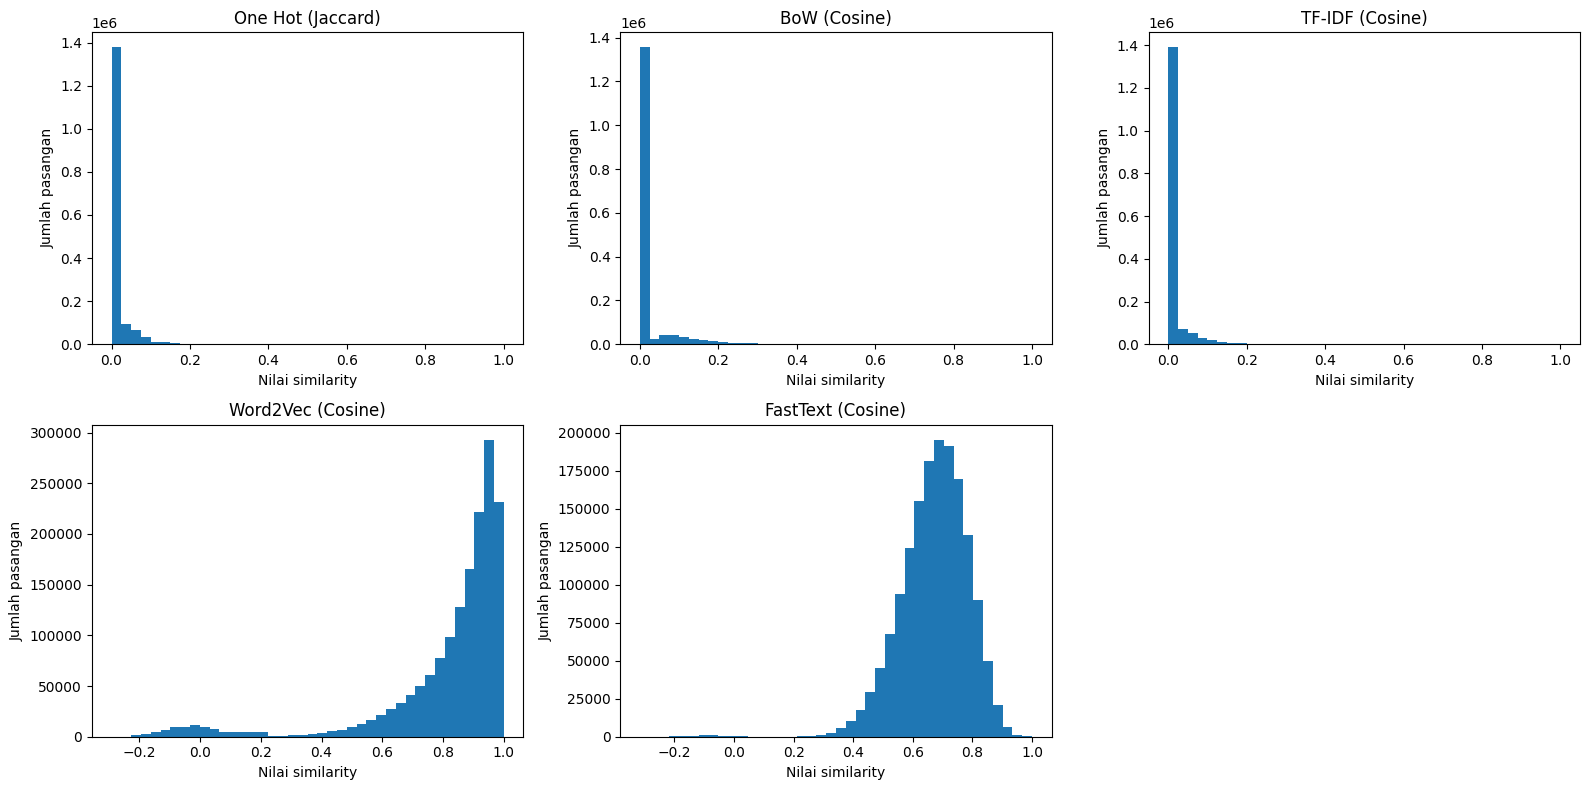

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, (nama, S) in zip(axes, semua.items()):
    n = S.shape[0]
    ax.hist(S[~np.eye(n, dtype=bool)], bins=40)
    ax.set_title(nama)
    ax.set_xlabel('Nilai similarity')
    ax.set_ylabel('Jumlah pasangan')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**3. Pencarian Komentar Paling Mirip dengan Query**

Query ditulis dalam bentuk yang sudah di-stemming (seperti kolom prepro), lalu dicari 10 komentar paling mirip dengan masing-masing metode.

**Hitung similarity query**

In [10]:
pd.set_option('display.max_colwidth', 120)

query = "bakar hutan kalimantan"   # bisa diganti, tulis dalam bentuk kata dasar

q_ohe = ohe_vec.transform([query]).toarray().astype(bool)

sims_query = {
    'One Hot (Jaccard)': np.nan_to_num(1 - cdist(Xb, q_ohe, metric='jaccard'))[:, 0],
    'BoW (Cosine)': cosine_similarity(X_bow, bow_vec.transform([query]))[:, 0],
    'TF-IDF (Cosine)': cosine_similarity(X_tfidf, tfidf_vec.transform([query]))[:, 0],
    'Word2Vec (Cosine)': cosine_similarity(
        X_w2v, doc_vector(query.split(), w2v_model.wv).reshape(1, -1))[:, 0],
    'FastText (Cosine)': cosine_similarity(
        X_ft, doc_vector(query.split(), ft_model.wv).reshape(1, -1))[:, 0],
}

def top_k(sims, k=10):
    idx = np.argsort(sims)[::-1][:k]
    tabel = pd.DataFrame({
        'Komentar asli': df['text_original'].iloc[idx].values,
        'Prepro': df['prepro'].iloc[idx].values,
        'Similarity': np.round(sims[idx], 4)
    })
    return tabel, set(idx)

top_hasil, top_idx = {}, {}
for nama, s in sims_query.items():
    top_hasil[nama], top_idx[nama] = top_k(s)

print("Query:", query)

Query: bakar hutan kalimantan


**Top 10 One Hot (Jaccard)**

In [11]:
print("TOP 10 - One Hot (Jaccard)")
top_hasil['One Hot (Jaccard)']

TOP 10 - One Hot (Jaccard)


,Komentar asli,Prepro,Similarity
0,habis hutan di Kalimantan terbakar.,habis hutan kalimantan bakar,0.7500
1,Sedangkan yg membakar hutan,yg bakar hutan,0.5000
2,kalimantan mana yang kebakaran kak,kalimantan mana bakar kak,0.4000
3,semoga lekas tidak ada lagi Kebakaran di Kalimantan amin 🙏,moga lekas bakar kalimantan amin,0.3333
4,salah itu ada orang bakar hutan demi sawit,salah orang bakar hutan sawit,0.3333
5,ada yang bakar,bakar,0.3333
6,mana didenger hutan dibakar dengan sengaja 🤣😆,mana didenger hutan bakar sengaja,0.3333
7,apakah ada oknum yg membakar hutan nya,oknum yg bakar hutan nya,0.3333
8,di bakar,bakar,0.3333
9,terbakar atau DI BAKAR,bakar bakar,0.3333


**Top 10 BoW (Cosine)**

In [12]:
print("TOP 10 - BoW (Cosine)")
top_hasil['BoW (Cosine)']

TOP 10 - BoW (Cosine)


,Komentar asli,Prepro,Similarity
0,habis hutan di Kalimantan terbakar.,habis hutan kalimantan bakar,0.8660
1,Sedangkan yg membakar hutan,yg bakar hutan,0.6667
2,SEPTEMBER jahat ada yang bakar hutan ada yang bakar rumah jangan sampai kalian komen ga gitu juga amin semoga tempat...,september jahat bakar hutan bakar rumah jangan kalian komen ga gitu amin moga tempat aku kalimantan bakar guys,0.5893
3,kalimantan mana yang kebakaran kak,kalimantan mana bakar kak,0.5774
4,ada yang bakar,bakar,0.5774
5,terbakar atau DI BAKAR,bakar bakar,0.5774
6,di bakar,bakar,0.5774
7,ya di bakar lagi,bakar,0.5774
8,mau nanya kebakaran hutan ini ada yg bakar apa kebakar sdri akibat kemarau,mau nanya bakar hutan yg bakar apa bakar sdri akibat kemarau,0.5601
9,apakah ada oknum yg membakar hutan nya,oknum yg bakar hutan nya,0.5164


**Top 10 TF-IDF (Cosine)**

In [13]:
print("TOP 10 - TF-IDF (Cosine)")
top_hasil['TF-IDF (Cosine)']

TOP 10 - TF-IDF (Cosine)


,Komentar asli,Prepro,Similarity
0,Sedangkan yg membakar hutan,yg bakar hutan,0.7197
1,habis hutan di Kalimantan terbakar.,habis hutan kalimantan bakar,0.6971
2,ada yang bakar,bakar,0.5103
3,terbakar atau DI BAKAR,bakar bakar,0.5103
4,ya di bakar lagi,bakar,0.5103
5,di bakar,bakar,0.5103
6,apakah ada oknum yg membakar hutan nya,oknum yg bakar hutan nya,0.4629
7,salah itu ada orang bakar hutan demi sawit,salah orang bakar hutan sawit,0.4492
8,kalimantan mana yang kebakaran kak,kalimantan mana bakar kak,0.4445
9,mau nanya kebakaran hutan ini ada yg bakar apa kebakar sdri akibat kemarau,mau nanya bakar hutan yg bakar apa bakar sdri akibat kemarau,0.4134


**Top 10 Word2Vec (Cosine)**

In [14]:
print("TOP 10 - Word2Vec (Cosine)")
top_hasil['Word2Vec (Cosine)']

TOP 10 - Word2Vec (Cosine)


,Komentar asli,Prepro,Similarity
0,habis hutan di Kalimantan terbakar.,habis hutan kalimantan bakar,0.9979
1,jhtt bngett yg bakar hutan ini ada rumhh hewann di sana😭😭😭,jhtt bngett yg bakar hutan rumhh hewann sana,0.9747
2,apakah ada oknum yg membakar hutan nya,oknum yg bakar hutan nya,0.9678
3,Sedangkan yg membakar hutan,yg bakar hutan,0.9669
4,semoga yang membakar hutan mendapatkan siksa berat,moga bakar hutan dapat siksa berat,0.9666
5,semoga yg bakar lahan kena azab pedih di dunia dan akhirat,moga yg bakar lahan kena azab pedih dunia akhirat,0.9652
6,sekrng Indonesia yang kebakaran,sekrng indonesia bakar,0.9602
7,byk satwa yg gosong terbakar,byk satwa yg gosong bakar,0.9575
8,Alam sudah marah...\nJika bencana berakhir... Tolak pembukaan lahan kelapa sawit total seluruh Kalimantan!\nPembukaa...,alam marah bencana akhir tolak buka lahan kelapa sawit total seluruh kalimantan buka lahan lahan tani hrs batas bang...,0.9518
9,ada yang mati terbakar,mati bakar,0.9500


**Top 10 FastText (Cosine)**

In [15]:
print("TOP 10 - FastText (Cosine)")
top_hasil['FastText (Cosine)']

TOP 10 - FastText (Cosine)


,Komentar asli,Prepro,Similarity
0,habis hutan di Kalimantan terbakar.,habis hutan kalimantan bakar,0.9814
1,Sedangkan yg membakar hutan,yg bakar hutan,0.9211
2,"ini memang real sengaja dibakar, hutan kami di bakarr",memang real sengaja bakar hutan bakarr,0.9023
3,"yang menjadi pertanyaan saat ini .\ndi Kalimantan hutan semua terbakar,\ntapi lahan sawit ribuan hektar aman aman sa...",jadi tanya kalimantan hutan semua bakar lahan sawit ribu hektar aman aman koq gak ikut bakar yah,0.9006
4,SEPTEMBER jahat ada yang bakar hutan ada yang bakar rumah jangan sampai kalian komen ga gitu juga amin semoga tempat...,september jahat bakar hutan bakar rumah jangan kalian komen ga gitu amin moga tempat aku kalimantan bakar guys,0.8790
5,kasihan dongg kan hutannya dibakar SMA bocah biadab,kasihan dongg kan hutan bakar sma bocah biadab,0.8762
6,penyebab kebakaran rata-rata peralihan dari lahan hutan jadi lahan sawit ini nyata dan saya lihat sendiri terutama d...,sebab bakar ratarata alih lahan hutan jadi lahan sawit nyata lihat sendiri utama jalan poros kalimantan,0.8760
7,apakah ada oknum yg membakar hutan nya,oknum yg bakar hutan nya,0.8745
8,kayaknya kalo hutan hujan Amazone ada di indonesia udah di bakar juga dijadiin kebun sawit,kayak kalo hutan hujan amazone indonesia udah bakar dijadiin kebun sawit,0.8695
9,Kalimantan lautan 🔥🔥🔥,kalimantan laut,0.8664


**Kesamaan hasil Top 10 antar metode**

In [16]:
nama_metode = list(top_idx)
overlap = pd.DataFrame(
    [[len(top_idx[a] & top_idx[b]) for b in nama_metode] for a in nama_metode],
    index=nama_metode, columns=nama_metode
)
print("Jumlah komentar yang sama di Top 10 antar dua metode (maks 10):")
overlap

Jumlah komentar yang sama di Top 10 antar dua metode (maks 10):


,One Hot (Jaccard),BoW (Cosine),TF-IDF (Cosine),Word2Vec (Cosine),FastText (Cosine)
One Hot (Jaccard),10,7,8,3,3
BoW (Cosine),7,10,9,3,4
TF-IDF (Cosine),8,9,10,3,3
Word2Vec (Cosine),3,3,3,10,3
FastText (Cosine),3,4,3,3,10


**Pasangan komentar paling mirip di seluruh data**

In [17]:
S = sim_tfidf.copy()
np.fill_diagonal(S, 0)
i, j = np.unravel_index(S.argmax(), S.shape)

print(f"Pasangan paling mirip (TF-IDF cosine = {S[i, j]:.4f})")
print("Komentar", i, ":", df.loc[i, 'text_original'])
print("Komentar", j, ":", df.loc[j, 'text_original'])

Pasangan paling mirip (TF-IDF cosine = 1.0000)
Komentar 119 : BENCANA atau RENCANA??
Komentar 861 : ini bencana atau rencana......


**ANALISIS HASIL TEXT SIMILARITY**

1. **Statistik similarity.** Dari 1265 komentar, rata-rata similarity antar pasangan paling rendah pada One Hot/Jaccard (0,0094) dan TF-IDF (0,0116), lalu BoW (0,0201), sedangkan Word2Vec (0,8146) dan FastText (0,6709) jauh lebih tinggi. Pada One Hot, BoW, dan TF-IDF hanya 15,30% pasangan komentar yang memiliki similarity lebih dari 0 dan nilai tengahnya 0, karena komentar TikTok pendek dan jarang berbagi kata. Pada Word2Vec dan FastText, 97,08% dan 99,70% pasangan memiliki similarity lebih dari 0 karena vektornya padat (setiap komentar punya nilai di semua 100 dimensi).

2. **Perbedaan nilai antar metode.** Nilai similarity Word2Vec dan FastText tinggi hampir di semua pasangan, sehingga nilai absolutnya kurang bisa dibaca sebagai "mirip secara makna" dan lebih tepat dipakai untuk mengurutkan peringkat. Nilai antar metode juga tidak bisa dibandingkan langsung karena skala dan cara menghitungnya berbeda.

3. **Jaccard (One Hot) vs Cosine (BoW).** Keduanya bertumpu pada kata yang sama-sama muncul, sehingga jumlah pasangan yang memiliki kemiripan sama (15,30%). Untuk data biner, nilai cosine selalu lebih besar atau sama dengan Jaccard, sesuai hasil rata-rata (0,0201 dibanding 0,0094). Cosine pada BoW juga mempertimbangkan jumlah kemunculan kata, sedangkan Jaccard hanya melihat ada atau tidaknya kata.

4. **Pencarian dengan query "bakar hutan kalimantan".** One Hot dan BoW menempatkan komentar "habis hutan di Kalimantan terbakar." di peringkat 1 (0,7500 dan 0,8660) karena memuat ketiga kata query. Pada TF-IDF, peringkat 1 berubah menjadi "Sedangkan yg membakar hutan" (0,7197) di atas komentar tersebut (0,6971). Hal ini kemungkinan karena TF-IDF memberi bobot lebih besar pada kata yang jarang muncul, sehingga kata lain pada komentar (misalnya "habis") ikut mempengaruhi nilainya. Komentar yang sangat pendek seperti "ada yang bakar" dan "di bakar" juga masuk Top 10 BoW dan TF-IDF dengan nilai cosine yang sama (0,5774 pada BoW) karena cosine tidak membedakan panjang komentar selama arah vektornya sama.

5. **Word2Vec dan FastText.** Komentar peringkat 1 pada keduanya sama dengan One Hot dan BoW, yaitu "habis hutan di Kalimantan terbakar." (0,9979 dan 0,9814). Peringkat berikutnya lebih beragam, misalnya "byk satwa yg gosong terbakar" dan "ada yang mati terbakar" pada Word2Vec, serta "Kalimantan lautan 🔥🔥🔥" dan "kayaknya kalo hutan hujan Amazone ada di indonesia udah di bakar juga" pada FastText. Keduanya menangkap kemiripan makna dan konteks, bukan hanya kata yang sama persis, tetapi sebagian hasilnya kurang relevan terhadap query.

6. **Kesamaan antar metode.** Top 10 One Hot, BoW, dan TF-IDF saling berdekatan (7 sampai 9 komentar sama; BoW dan TF-IDF paling mirip dengan 9 komentar sama). Sebaliknya, Word2Vec dan FastText hanya berbagi 3 sampai 4 komentar dengan ketiga metode tersebut dan 3 komentar satu sama lain. Hal ini wajar karena kelompok pertama berbasis kecocokan kata, sedangkan kelompok kedua berbasis vektor makna.

7. **Pasangan komentar paling mirip** adalah komentar ke-119 ("BENCANA atau RENCANA??") dan ke-861 ("ini bencana atau rencana......") dengan cosine TF-IDF 1,0000. Keduanya berbeda saat cleaning (komentar kedua memuat kata "ini"), tetapi menjadi identik setelah stopword dihapus dan stemming ("bencana rencana"). Karena itu, penghapusan duplikat pada Chapter 4 yang dilakukan sebelum stopword removal dan stemming belum menangkap komentar seperti ini.

8. **Kesimpulan.** Untuk mencari komentar berdasarkan kata kunci, TF-IDF dengan cosine similarity paling informatif karena mempertimbangkan bobot kata. Jaccard dan BoW cocok sebagai pembanding sederhana. Word2Vec dan FastText mampu menemukan komentar yang berkaitan secara makna, tetapi nilai similarity-nya cenderung tinggi di semua pasangan dan kualitasnya dibatasi oleh komentar yang pendek serta bahasa yang informal.